# JobMatch AI - Recomendação Inteligente de Vagas e Candidatos

## Bases utilizadas

* LinkedIn Job Postings 2023-2024: vagas reais, descrições, empresas, localização e salário
* Resume-JD-Match: pares currículo-vaga rotulados como No Fit, Potential Fit e Good Fit
* Job Skill Set Dataset: vocabulário de habilidades por cargo

## Estratégia

* TF-IDF + similaridade por cosseno para recomendação
* Logistic Regression para classificação Fit / No Fit
* Random Forest Regressor para estimativa salarial
* Job Skill Set como apoio para extração de skills

# Instalação

In [1]:
!pip -q install kagglehub datasets

# Autenticação

In [2]:
import os
from google.colab import userdata

token_kaggle = userdata.get("KAGGLE_API_TOKEN")

if token_kaggle is None:
    raise ValueError("Secret KAGGLE_API_TOKEN não encontrado no Colab")

os.environ["KAGGLE_API_TOKEN"] = token_kaggle

print("Token Kaggle carregado com segurança.")

Token Kaggle carregado com segurança.


# Imports

In [3]:
from pathlib import Path
from collections import Counter

import ast
import re
import unicodedata
import warnings

import kagglehub
import numpy as np
import pandas as pd

from datasets import load_dataset
from joblib import dump

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from scipy.sparse import csr_matrix

In [5]:
import matplotlib.pyplot as plt

In [6]:
from pathlib import Path
from google.colab import files

# Preparar funções de apoio

Nesse etapa foi criado funçõe para limpar textos, carregar arquivos CSV, tratar listas de skills e adaptar termos em português para inglês.

In [7]:
def normalizar_texto(valor):
    if not isinstance(valor, str):
        return ""

    texto = valor.strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(caractere for caractere in texto if not unicodedata.combining(caractere))
    texto = re.sub(r"[^a-z0-9\s+#.\-]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


def converter_lista_skills(valor):
    if isinstance(valor, list):
        return [str(skill).strip() for skill in valor if str(skill).strip()]

    if pd.isna(valor):
        return []

    texto = str(valor).strip()

    try:
        lista = ast.literal_eval(texto)

        if isinstance(lista, list):
            return [str(skill).strip() for skill in lista if str(skill).strip()]

    except Exception:
        pass

    for separador in [";", ",", "|"]:
        if separador in texto:
            return [skill.strip() for skill in texto.split(separador) if skill.strip()]

    return [texto] if texto else []


def carregar_primeiro_csv(caminho_pasta, nome_provavel=None):
    arquivos_csv = list(Path(caminho_pasta).rglob("*.csv"))

    if not arquivos_csv:
        raise FileNotFoundError(f"Nenhum CSV encontrado em {caminho_pasta}")

    if nome_provavel is not None:
        for caminho_csv in arquivos_csv:
            if nome_provavel.lower() in caminho_csv.name.lower():
                print("Carregando:", caminho_csv)
                return pd.read_csv(caminho_csv)

    print("Carregando:", arquivos_csv[0])
    return pd.read_csv(arquivos_csv[0])

In [8]:
termos_portugues_ingles = {
    "aprendizado de maquina": "machine learning",
    "machine learning": "machine learning",
    "inteligencia artificial": "artificial intelligence",
    "ia": "artificial intelligence",
    "analise de dados": "data analysis",
    "analista de dados": "data analyst",
    "ciencia de dados": "data science",
    "cientista de dados": "data scientist",
    "engenharia de dados": "data engineering",
    "engenheiro de dados": "data engineer",
    "visualizacao de dados": "data visualization",
    "modelagem preditiva": "predictive modeling",
    "modelo preditivo": "predictive modeling",
    "avaliacao de modelos": "model evaluation",
    "pipeline de dados": "data pipeline",
    "pipelines de dados": "data pipelines",
    "banco de dados": "database",
    "bancos de dados": "databases",
    "estatistica": "statistics",
    "nuvem": "cloud",
    "computacao em nuvem": "cloud computing",
    "aprendizado profundo": "deep learning",
    "processamento de linguagem natural": "natural language processing",
    "linguagem natural": "natural language processing",
    "dados": "data",
    "paineis": "dashboards",
    "painel": "dashboard",
    "indicadores": "business indicators",
    "api": "api",
    "apis": "apis",
}


def normalizar_curriculo_usuario(valor):
    texto = normalizar_texto(valor)

    pares_ordenados = sorted(
        termos_portugues_ingles.items(),
        key=lambda item: len(item[0]),
        reverse=True,
    )

    for termo_portugues, termo_ingles in pares_ordenados:
        termo_normalizado = normalizar_texto(termo_portugues)

        texto = re.sub(
            r"(?<![a-z0-9])" + re.escape(termo_normalizado) + r"(?![a-z0-9])",
            termo_ingles,
            texto,
        )

    return texto

# Baixar e carregar datasets

Nessa etapa, os datasets do projeto são baixados e carregados no notebook


In [9]:
caminho_base_linkedin = Path(
    kagglehub.dataset_download("arshkon/linkedin-job-postings")
)

caminho_base_skills = Path(
    kagglehub.dataset_download("batuhanmutlu/job-skill-set")
)

base_resume_jd = load_dataset("facehuggerapoorv/resume-jd-match")

dados_linkedin = carregar_primeiro_csv(
    caminho_base_linkedin,
    nome_provavel="postings",
)

dados_skills_cargos = carregar_primeiro_csv(
    caminho_base_skills,
)

dados_pares_curriculo_vaga = pd.concat(
    [
        base_resume_jd[nome_split].to_pandas()
        for nome_split in base_resume_jd.keys()
    ],
    ignore_index=True,
)

print("LinkedIn:", dados_linkedin.shape)
print("Job Skill Set:", dados_skills_cargos.shape)
print("Resume-JD-Match:", dados_pares_curriculo_vaga.shape)

print("\nColunas LinkedIn:")
print(dados_linkedin.columns.tolist())

print("\nColunas Job Skill Set:")
print(dados_skills_cargos.columns.tolist())

print("\nColunas Resume-JD-Match:")
print(dados_pares_curriculo_vaga.columns.tolist())

100%|██████████| 159M/159M [00:01<00:00, 124MB/s]

Extracting files...


100%|██████████| 1.50M/1.50M [00:00<00:00, 26.2MB/s]

Extracting files...


README.md:   0%|          | 0.00/411 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.07M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

Carregando: /root/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13/postings.csv
Carregando: /root/.cache/kagglehub/datasets/batuhanmutlu/job-skill-set/versions/2/all_job_post.csv
LinkedIn: (123849, 31)
Job Skill Set: (1167, 5)
Resume-JD-Match: (8000, 2)

Colunas LinkedIn:
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

Colunas Job Skill Set:
['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']

Colunas Resume-JD-Match:
['text', 'label']


# Análise geral das bases

Aqui ocorre a comparação do tamanho dos datasets utilizados no projeto observando a quantidade de linhas e colunas de cada base.

,base,linhas,colunas
0,LinkedIn Job Postings,123849,31
1,Job Skill Set,1167,5
2,Resume-JD-Match,8000,2


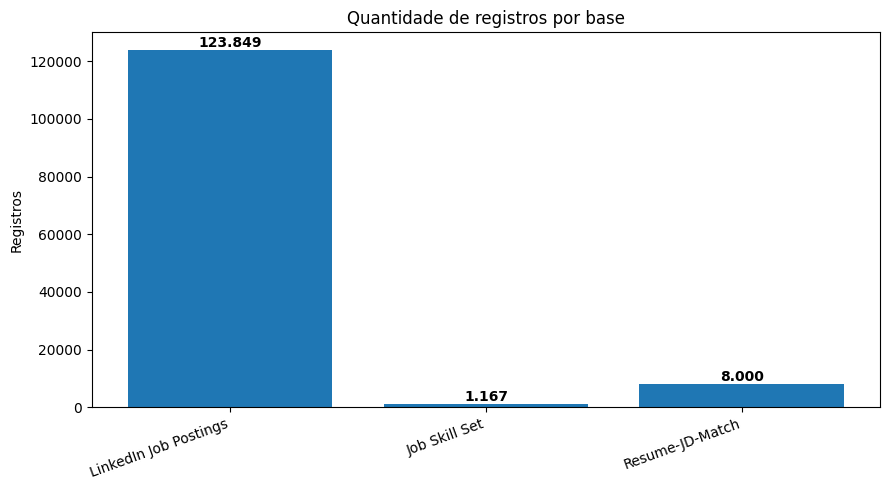

In [10]:
resumo_bases = pd.DataFrame(
    {
        "base": ["LinkedIn Job Postings", "Job Skill Set", "Resume-JD-Match"],
        "linhas": [
            len(dados_linkedin),
            len(dados_skills_cargos),
            len(dados_pares_curriculo_vaga),
        ],
        "colunas": [
            dados_linkedin.shape[1],
            dados_skills_cargos.shape[1],
            dados_pares_curriculo_vaga.shape[1],
        ],
    }
)

display(resumo_bases)

plt.figure(figsize=(9, 5))

barras = plt.bar(
    resumo_bases["base"],
    resumo_bases["linhas"],
)

plt.title("Quantidade de registros por base")
plt.ylabel("Registros")
plt.xticks(rotation=20, ha="right")

for barra in barras:
    valor = int(barra.get_height())

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{valor:,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# Distribuição dos rótulos do Resume-JD-Match

A distribuição dos rótulos mostra como os pares currículo-vaga estão classificados na base usada para treinar o modelo Fit/No Fit. A classe No Fit possui mais exemplos, enquanto Potential Fit e Good Fit representam casos de compatibilidade parcial ou positiva


,quantidade
label,
No Fit,4000
Potential Fit,2000
Good Fit,2000


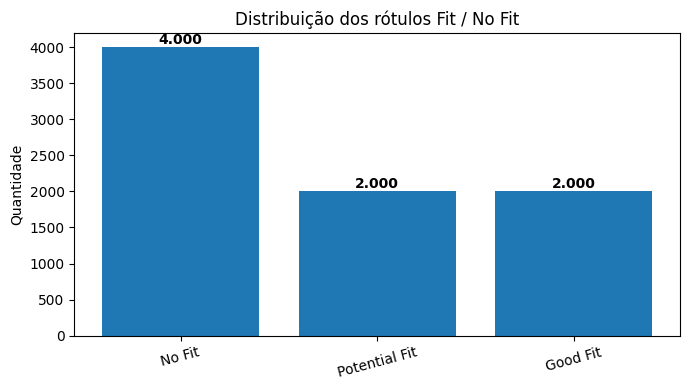

In [11]:
distribuicao_labels = dados_pares_curriculo_vaga["label"].value_counts()

display(distribuicao_labels.to_frame("quantidade"))

plt.figure(figsize=(7, 4))

barras = plt.bar(
    distribuicao_labels.index,
    distribuicao_labels.values,
)

plt.title("Distribuição dos rótulos Fit / No Fit")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)

for barra in barras:
    valor = int(barra.get_height())

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{valor:,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# Tipos de trabalho no LinkedIn

Este gráfico mostra os formatos de trabalho mais frequentes na base de vagas do LinkedIn, como tempo integral, contrato, meio período, estágio e outros tipos.

,quantidade
formatted_work_type,
Full-time,98814
Contract,12117
Part-time,9696
Temporary,1190
Internship,983
Volunteer,562
Other,487


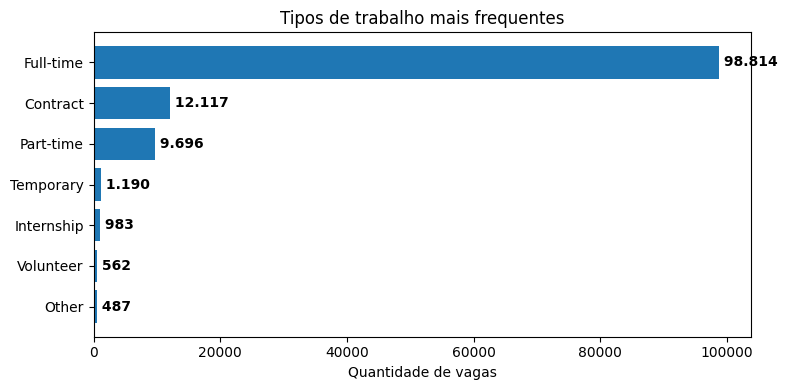

In [12]:
if "formatted_work_type" in dados_linkedin.columns:
    tipos_trabalho = dados_linkedin["formatted_work_type"].value_counts().head(10)

    display(tipos_trabalho.to_frame("quantidade"))

    plt.figure(figsize=(8, 4))

    barras = plt.barh(
        tipos_trabalho.index[::-1],
        tipos_trabalho.values[::-1],
    )

    plt.title("Tipos de trabalho mais frequentes")
    plt.xlabel("Quantidade de vagas")

    for barra in barras:
        valor = int(barra.get_width())

        plt.text(
            barra.get_width(),
            barra.get_y() + barra.get_height() / 2,
            f" {valor:,}".replace(",", "."),
            va="center",
            fontsize=10,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()

A maior parte das vagas está concentrada no formato `Full-time`, seguido por `Contract` e `Part-time`. Os demais tipos de trabalho aparecem em volume menor na base analisada.


# Níveis de experiência no LinkedIn


,quantidade
formatted_experience_level,
Mid-Senior level,41489
Entry level,36708
Associate,9826
Director,3746
Internship,1449
Executive,1222


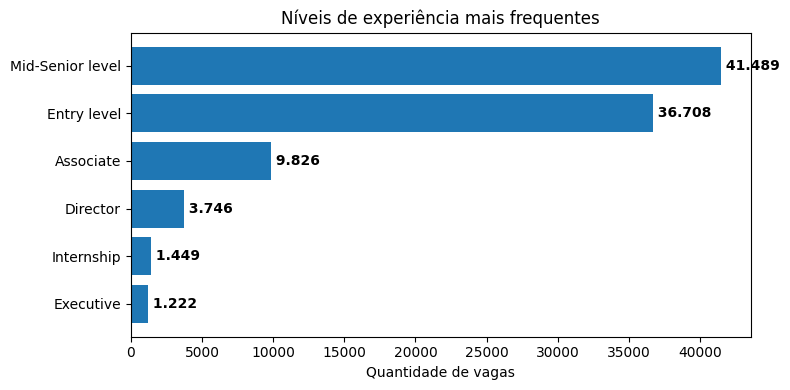

In [13]:
if "formatted_experience_level" in dados_linkedin.columns:
    niveis_experiencia = dados_linkedin["formatted_experience_level"].value_counts().head(10)

    display(niveis_experiencia.to_frame("quantidade"))

    plt.figure(figsize=(8, 4))

    barras = plt.barh(
        niveis_experiencia.index[::-1],
        niveis_experiencia.values[::-1],
    )

    plt.title("Níveis de experiência mais frequentes")
    plt.xlabel("Quantidade de vagas")

    for barra in barras:
        valor = int(barra.get_width())

        plt.text(
            barra.get_width(),
            barra.get_y() + barra.get_height() / 2,
            f" {valor:,}".replace(",", "."),
            va="center",
            fontsize=10,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()

A base possui maior concentração de vagas nos níveis `Mid-Senior level` e `Entry level`. Os níveis `Associate`, `Director`, `Internship` e `Executive` aparecem em menor quantidade.


# preparar vagas do LinkedIn

Aqui os dados das vagas são padronizados para uso nos modelos de recomendação, classificação e estimativa salarial. Nesse sentido, são selecionadas as principais informações da vaga, como título, empresa, localização, descrição, tipo de trabalho, nível de experiência, skills e salários. Em seguida é criado o campo texto_vaga que reúne as informações textuais usadas no processamento de linguagem natural e o campo salario_alvo, utilizado como referência para o modelo de regressão.

In [14]:
dados_vagas = dados_linkedin.copy()

colunas_base = [
    "job_id",
    "company_name",
    "title",
    "description",
    "location",
    "formatted_work_type",
    "formatted_experience_level",
    "skills_desc",
    "min_salary",
    "max_salary",
    "med_salary",
    "normalized_salary",
    "currency",
]

for coluna in colunas_base:
    if coluna not in dados_vagas.columns:
        dados_vagas[coluna] = np.nan

dados_vagas = dados_vagas[colunas_base].copy()
dados_vagas = dados_vagas.dropna(subset=["title", "description"]).copy()

dados_vagas["texto_vaga"] = (
    dados_vagas["title"].fillna("") + " "
    + dados_vagas["description"].fillna("") + " "
    + dados_vagas["skills_desc"].fillna("") + " "
    + dados_vagas["formatted_work_type"].fillna("") + " "
    + dados_vagas["formatted_experience_level"].fillna("")
).apply(normalizar_texto)

dados_vagas = dados_vagas[dados_vagas["texto_vaga"].str.len() >= 80].copy()

for coluna in ["min_salary", "max_salary", "med_salary", "normalized_salary"]:
    dados_vagas[coluna] = pd.to_numeric(dados_vagas[coluna], errors="coerce")

dados_vagas["salario_alvo"] = dados_vagas["normalized_salary"]

sem_salario_normalizado = dados_vagas["salario_alvo"].isna()
dados_vagas.loc[sem_salario_normalizado, "salario_alvo"] = dados_vagas.loc[
    sem_salario_normalizado,
    "med_salary",
]

sem_salario_mediano = dados_vagas["salario_alvo"].isna()
dados_vagas.loc[sem_salario_mediano, "salario_alvo"] = (
    dados_vagas.loc[sem_salario_mediano, "min_salary"]
    + dados_vagas.loc[sem_salario_mediano, "max_salary"]
) / 2

dados_vagas["company_name"] = dados_vagas["company_name"].fillna("Empresa não informada")
dados_vagas["location"] = dados_vagas["location"].fillna("Local não informado")
dados_vagas["currency"] = dados_vagas["currency"].fillna("USD")

quantidade_maxima_vagas = 30000

if len(dados_vagas) > quantidade_maxima_vagas:
    dados_vagas = dados_vagas.sample(
        quantidade_maxima_vagas,
        random_state=RANDOM_STATE,
    ).reset_index(drop=True)

print("Vagas preparadas:", dados_vagas.shape)

display(
    dados_vagas[
        [
            "job_id",
            "title",
            "company_name",
            "location",
            "salario_alvo",
            "currency",
        ]
    ].head()
)

Vagas preparadas: (30000, 15)


,job_id,title,company_name,location,salario_alvo,currency
0,3895523924,Regional Accounting Specialist - Accounting,Marsh McLennan Agency,"Minneapolis, MN",NaN,USD
1,3905394718,Sales Associate,J.Crew Factory,"Salt Lake City, UT",33280.0,USD
2,3905339222,"Program Manager, Principal",Blue Shield of California,"California, United States",170500.0,USD
3,3905340040,Austin 33 (Nutty Brown/Hwy 290) Dairy - Custom...,H-E-B,"Austin, TX",NaN,USD
4,3900963484,Senior Graphic Designer,Post Meridiem,Denver Metropolitan Area,80000.0,USD


# preparar vocabulário de skills

Nessa etapa, a base Job Skill Set é utilizada para construir um vocabulário controlado de competências técnicas. As skills são normalizadas, termos genéricos são filtrados e uma lista manual de tecnologias relevantes é adicionada para melhorar a identificação de skills compatíveis e faltantes nas recomendações.

In [15]:
dados_skills = dados_skills_cargos.copy()

if "job_skill_set" not in dados_skills.columns:
    raise ValueError("A base Job Skill Set não possui a coluna job_skill_set")

dados_skills["lista_skills"] = dados_skills["job_skill_set"].apply(converter_lista_skills)

skills_manuais = [
    "python",
    "sql",
    "pandas",
    "numpy",
    "scikit-learn",
    "machine learning",
    "deep learning",
    "data science",
    "data analysis",
    "data visualization",
    "statistics",
    "statistical analysis",
    "predictive modeling",
    "model evaluation",
    "power bi",
    "tableau",
    "excel",
    "docker",
    "kubernetes",
    "git",
    "github",
    "fastapi",
    "flask",
    "api",
    "apis",
    "etl",
    "data pipeline",
    "data pipelines",
    "aws",
    "azure",
    "gcp",
    "cloud",
    "tensorflow",
    "pytorch",
    "nlp",
    "natural language processing",
    "spark",
    "airflow",
    "databricks",
    "bigquery",
    "postgresql",
    "mysql",
    "snowflake",
    "dbt",
    "linux",
    "java",
    "javascript",
    "typescript",
    "react",
    "node",
]

skills_bloqueadas = {
    "data",
    "business",
    "management",
    "communication",
    "leadership",
    "research",
    "analysis",
    "analytics",
    "programming",
    "focus",
    "other",
    "customer service",
    "attention to detail",
    "problem solving",
    "written communication",
    "verbal communication",
    "teamwork",
    "collaboration",
    "planning",
    "organization",
    "organizational skills",
    "time management",
    "microsoft office",
    "computer science",
}


def validar_skill(skill_normalizada):
    if not skill_normalizada:
        return False

    if skill_normalizada in skills_bloqueadas:
        return False

    if len(skill_normalizada) < 2:
        return False

    if len(skill_normalizada.split()) > 4:
        return False

    return True


contador_skills = Counter()
skill_original_por_normalizada = {}

for lista_skills in dados_skills["lista_skills"]:
    if not isinstance(lista_skills, list):
        continue

    for skill in lista_skills:
        skill_original = str(skill).strip()
        skill_normalizada = normalizar_texto(skill_original)

        if not validar_skill(skill_normalizada):
            continue

        contador_skills[skill_normalizada] += 1

        if skill_normalizada not in skill_original_por_normalizada:
            skill_original_por_normalizada[skill_normalizada] = skill_original

for skill in skills_manuais:
    skill_normalizada = normalizar_texto(skill)
    contador_skills[skill_normalizada] += 100
    skill_original_por_normalizada[skill_normalizada] = skill

skills_vocabulario = sorted(
    contador_skills.keys(),
    key=lambda skill: (contador_skills[skill], len(skill.split()), len(skill)),
    reverse=True,
)[:2000]

vocabulario_skills = {
    skill: indice
    for indice, skill in enumerate(skills_vocabulario)
}

vetorizador_skills = CountVectorizer(
    vocabulary=vocabulario_skills,
    ngram_range=(1, 4),
    lowercase=False,
    token_pattern=r"(?u)\b[a-zA-Z0-9+#.\-]+\b",
)

nomes_skills = np.array(vetorizador_skills.get_feature_names_out())

print("Quantidade de skills no vocabulário:", len(skills_vocabulario))
print("Exemplos:", skills_vocabulario[:40])

Quantidade de skills no vocabulário: 2000
Exemplos: ['adaptability', 'data analysis', 'interpersonal skills', 'relationship building', 'project management', 'excel', 'negotiation', 'sales', 'presentation skills', 'business development', 'financial analysis', 'sql', 'strategic thinking', 'analytical skills', 'power bi', 'python', 'azure', 'data visualization', 'linux', 'java', 'tableau', 'team collaboration', 'javascript', 'statistical analysis', 'machine learning', 'self-motivation', 'etl', 'aws', 'employee relations', 'predictive modeling', 'spark', 'data science', 'statistics', 'kubernetes', 'databricks', 'github', 'docker', 'react', 'git', 'api']


# Comparação de skills

São definidas funções para extrair skills das vagas, comparar com o currículo informado, calcular a cobertura de competências e gerar uma sugestão simples de desenvolvimento.

In [16]:
def extrair_skills_de_textos(textos, limite=15):
    textos_normalizados = [normalizar_texto(texto) for texto in textos]
    matriz_skills = vetorizador_skills.transform(textos_normalizados)

    resultados = []

    for indice_linha in range(matriz_skills.shape[0]):
        indices_skills = matriz_skills[indice_linha].nonzero()[1]

        if len(indices_skills) == 0:
            resultados.append([])
            continue

        skills_normalizadas = nomes_skills[indices_skills]

        skills_ordenadas = sorted(
            skills_normalizadas,
            key=lambda skill: (len(skill.split()), len(skill)),
            reverse=True,
        )

        skills_finais = []

        for skill_normalizada in skills_ordenadas:
            skill_original = skill_original_por_normalizada.get(
                skill_normalizada,
                skill_normalizada,
            )

            if skill_original not in skills_finais:
                skills_finais.append(skill_original)

            if len(skills_finais) >= limite:
                break

        resultados.append(skills_finais)

    return resultados


def comparar_skills(texto_curriculo, skills_vaga):
    curriculo_normalizado = normalizar_texto(texto_curriculo)

    skills_compativeis = []
    skills_faltantes = []

    for skill in skills_vaga:
        skill_original = str(skill).strip()
        skill_normalizada = normalizar_texto(skill_original)

        if not skill_normalizada:
            continue

        if skill_normalizada in curriculo_normalizado:
            skills_compativeis.append(skill_original)
        else:
            skills_faltantes.append(skill_original)

    return skills_compativeis, skills_faltantes


def calcular_cobertura_skills(skills_compativeis, skills_faltantes):
    total = len(skills_compativeis) + len(skills_faltantes)

    if total == 0:
        return 0.0

    return len(skills_compativeis) / total


def gerar_sugestao_desenvolvimento(skills_faltantes):
    if not skills_faltantes:
        return "Perfil bem alinhado. Manter portfólio atualizado e preparar cases práticos."

    principais = skills_faltantes[:5]

    return (
        "Priorizar desenvolvimento em: "
        + ", ".join(principais)
        + ". Criar projeto prático e adicionar evidências ao currículo."
    )

# Classificador Fit / No Fit

In [17]:
def converter_rotulo_fit(valor):
    rotulo = normalizar_texto(str(valor))

    if rotulo == "no fit":
        return 0

    if rotulo in {"potential fit", "good fit", "fit"}:
        return 1

    return None


def extrair_curriculo_e_vaga(texto):
    texto_original = str(texto)

    padrao_vaga = re.search(
        r"job description\s*<<(.+?)>>",
        texto_original,
        flags=re.IGNORECASE | re.DOTALL,
    )

    padrao_curriculo = re.search(
        r"resume\s*<<(.+?)>>",
        texto_original,
        flags=re.IGNORECASE | re.DOTALL,
    )

    texto_vaga = padrao_vaga.group(1) if padrao_vaga else texto_original
    texto_curriculo = padrao_curriculo.group(1) if padrao_curriculo else texto_original

    return pd.Series(
        {
            "texto_curriculo": normalizar_texto(texto_curriculo),
            "texto_vaga": normalizar_texto(texto_vaga),
        }
    )


def selecionar_texto_par(dados):
    return dados["texto_par"].fillna("").astype(str).values


class FeaturesComparacaoCurriculoVaga(BaseEstimator, TransformerMixin):
    def __init__(self, skills_base=None, max_features=10000):
        self.skills_base = skills_base
        self.max_features = max_features

    def fit(self, dados, y=None):
        textos = pd.concat(
            [
                dados["texto_curriculo"].fillna("").astype(str),
                dados["texto_vaga"].fillna("").astype(str),
            ],
            ignore_index=True,
        )

        self.vetorizador_similaridade = TfidfVectorizer(
            max_features=self.max_features,
            ngram_range=(1, 2),
            min_df=2,
            stop_words="english",
            sublinear_tf=True,
            norm="l2",
        )

        self.vetorizador_similaridade.fit(textos)

        self.skills_normalizadas = []

        if self.skills_base is not None:
            for skill in self.skills_base[:1000]:
                skill_normalizada = normalizar_texto(skill)

                if skill_normalizada:
                    self.skills_normalizadas.append(skill_normalizada)

        return self

    def transform(self, dados):
        textos_curriculo = dados["texto_curriculo"].fillna("").astype(str).values
        textos_vaga = dados["texto_vaga"].fillna("").astype(str).values

        matriz_curriculo = self.vetorizador_similaridade.transform(textos_curriculo)
        matriz_vaga = self.vetorizador_similaridade.transform(textos_vaga)

        similaridade_tfidf = np.asarray(
            matriz_curriculo.multiply(matriz_vaga).sum(axis=1)
        ).ravel()

        features = []

        for texto_curriculo, texto_vaga, similaridade in zip(
            textos_curriculo,
            textos_vaga,
            similaridade_tfidf,
        ):
            tokens_curriculo = set(texto_curriculo.split())
            tokens_vaga = set(texto_vaga.split())

            if len(tokens_curriculo | tokens_vaga) == 0:
                jaccard = 0.0
            else:
                jaccard = len(tokens_curriculo & tokens_vaga) / len(
                    tokens_curriculo | tokens_vaga
                )

            skills_vaga = [
                skill for skill in self.skills_normalizadas if skill in texto_vaga
            ]

            if len(skills_vaga) == 0:
                cobertura_skills = 0.0
            else:
                skills_curriculo = [
                    skill for skill in skills_vaga if skill in texto_curriculo
                ]

                cobertura_skills = len(skills_curriculo) / len(skills_vaga)

            tamanho_curriculo = len(texto_curriculo.split())
            tamanho_vaga = len(texto_vaga.split())

            if tamanho_vaga == 0:
                razao_tamanho = 0.0
            else:
                razao_tamanho = min(tamanho_curriculo / tamanho_vaga, 3.0)

            features.append(
                [
                    similaridade,
                    jaccard,
                    cobertura_skills,
                    tamanho_curriculo / 1000,
                    tamanho_vaga / 1000,
                    razao_tamanho,
                ]
            )

        return csr_matrix(np.array(features))


def criar_classificador_linear_svc():
    modelo_base = LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    try:
        return CalibratedClassifierCV(
            estimator=modelo_base,
            cv=3,
            method="sigmoid",
        )
    except TypeError:
        return CalibratedClassifierCV(
            base_estimator=modelo_base,
            cv=3,
            method="sigmoid",
        )


def criar_pipeline_classificacao(classificador):
    features = FeatureUnion(
        [
            (
                "tfidf_palavras",
                Pipeline(
                    [
                        (
                            "selecionar_texto",
                            FunctionTransformer(
                                selecionar_texto_par,
                                validate=False,
                            ),
                        ),
                        (
                            "tfidf",
                            TfidfVectorizer(
                                max_features=30000,
                                ngram_range=(1, 3),
                                min_df=2,
                                stop_words="english",
                                sublinear_tf=True,
                            ),
                        ),
                    ]
                ),
            ),
            (
                "tfidf_caracteres",
                Pipeline(
                    [
                        (
                            "selecionar_texto",
                            FunctionTransformer(
                                selecionar_texto_par,
                                validate=False,
                            ),
                        ),
                        (
                            "tfidf",
                            TfidfVectorizer(
                                max_features=15000,
                                analyzer="char_wb",
                                ngram_range=(3, 5),
                                min_df=2,
                                sublinear_tf=True,
                            ),
                        ),
                    ]
                ),
            ),
            (
                "features_comparacao",
                FeaturesComparacaoCurriculoVaga(
                    skills_base=skills_vocabulario,
                    max_features=10000,
                ),
            ),
        ]
    )

    return Pipeline(
        [
            ("features", features),
            ("classificador", classificador),
        ]
    )


dados_classificacao = dados_pares_curriculo_vaga[["text", "label"]].copy()

dados_classificacao[["texto_curriculo", "texto_vaga"]] = dados_classificacao[
    "text"
].apply(extrair_curriculo_e_vaga)

dados_classificacao["texto_par"] = (
    "curriculo "
    + dados_classificacao["texto_curriculo"]
    + " vaga "
    + dados_classificacao["texto_vaga"]
)

dados_classificacao["rotulo_fit"] = dados_classificacao["label"].apply(
    converter_rotulo_fit
)

dados_classificacao = dados_classificacao.dropna(
    subset=["texto_par", "texto_curriculo", "texto_vaga", "rotulo_fit"]
).copy()

dados_classificacao["rotulo_fit"] = dados_classificacao["rotulo_fit"].astype(int)

print("Distribuição original:")
print(dados_classificacao["label"].value_counts())

print("\nDistribuição binária:")
print(dados_classificacao["rotulo_fit"].value_counts())


Path("data/processed").mkdir(parents=True, exist_ok=True)

colunas_exportacao = [
    "texto_par",
    "texto_curriculo",
    "texto_vaga",
    "rotulo_fit",
]

caminho_exportacao = "data/processed/dados_classificacao_fit.csv"

dados_classificacao[colunas_exportacao].to_csv(
    caminho_exportacao,
    index=False,
    encoding="utf-8",
)

print("\nArquivo de classificação exportado:")
print(caminho_exportacao)
print(dados_classificacao[colunas_exportacao].shape)

files.download(caminho_exportacao)


dados_entrada = dados_classificacao[
    [
        "texto_par",
        "texto_curriculo",
        "texto_vaga",
    ]
].copy()

rotulos = dados_classificacao["rotulo_fit"]

dados_treino, dados_teste, rotulos_treino, rotulos_teste = train_test_split(
    dados_entrada,
    rotulos,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=rotulos,
)

modelos_candidatos = {
    "logistic_regression_melhorada": LogisticRegression(
        C=2.0,
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "linear_svc_calibrado": criar_classificador_linear_svc(),
}

resultados_modelos = []
modelos_treinados = {}

for nome_modelo, classificador in modelos_candidatos.items():
    print("\nTreinando:", nome_modelo)

    modelo = criar_pipeline_classificacao(classificador)
    modelo.fit(dados_treino, rotulos_treino)

    previsoes = modelo.predict(dados_teste)

    acuracia = accuracy_score(rotulos_teste, previsoes)
    f1_macro = f1_score(rotulos_teste, previsoes, average="macro")

    resultados_modelos.append(
        {
            "modelo": nome_modelo,
            "acuracia": acuracia,
            "f1_macro": f1_macro,
        }
    )

    modelos_treinados[nome_modelo] = modelo

metricas_comparacao_modelos = pd.DataFrame(resultados_modelos).sort_values(
    by="f1_macro",
    ascending=False,
)

display(metricas_comparacao_modelos)

melhor_nome_modelo = metricas_comparacao_modelos.iloc[0]["modelo"]
modelo_classificacao_fit = modelos_treinados[melhor_nome_modelo]

print("\nMelhor modelo:", melhor_nome_modelo)

probabilidades_teste = modelo_classificacao_fit.predict_proba(dados_teste)[:, 1]

resultados_limiares = []

for limiar in np.arange(0.30, 0.71, 0.01):
    previsoes_limiar = (probabilidades_teste >= limiar).astype(int)

    resultados_limiares.append(
        {
            "limiar": round(float(limiar), 2),
            "acuracia": accuracy_score(rotulos_teste, previsoes_limiar),
            "f1_macro": f1_score(rotulos_teste, previsoes_limiar, average="macro"),
        }
    )

metricas_limiares = pd.DataFrame(resultados_limiares).sort_values(
    by="f1_macro",
    ascending=False,
)

display(metricas_limiares.head(10))

LIMIAR_MODELO_FIT = float(metricas_limiares.iloc[0]["limiar"])

previsoes_teste = (probabilidades_teste >= LIMIAR_MODELO_FIT).astype(int)

metricas_classificacao = {
    "modelo": melhor_nome_modelo,
    "limiar": LIMIAR_MODELO_FIT,
    "acuracia": accuracy_score(rotulos_teste, previsoes_teste),
    "f1_macro": f1_score(rotulos_teste, previsoes_teste, average="macro"),
    "matriz_confusao": confusion_matrix(rotulos_teste, previsoes_teste),
}

print("\nLimiar escolhido:", LIMIAR_MODELO_FIT)
print("Acurácia final:", metricas_classificacao["acuracia"])
print("F1 macro final:", metricas_classificacao["f1_macro"])

print("\nMatriz de confusão:")
print(metricas_classificacao["matriz_confusao"])

print("\nRelatório:")
print(
    classification_report(
        rotulos_teste,
        previsoes_teste,
        target_names=["No Fit", "Fit"],
    )
)

Distribuição original:
label
No Fit           4000
Potential Fit    2000
Good Fit         2000
Name: count, dtype: int64

Distribuição binária:
rotulo_fit
0    4000
1    4000
Name: count, dtype: int64

Arquivo de classificação exportado:
data/processed/dados_classificacao_fit.csv
(8000, 4)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Treinando: logistic_regression_melhorada

Treinando: linear_svc_calibrado


,modelo,acuracia,f1_macro
1,linear_svc_calibrado,0.92125,0.921248
0,logistic_regression_melhorada,0.86375,0.863724



Melhor modelo: linear_svc_calibrado


,limiar,acuracia,f1_macro
20,0.50,0.921250,0.921248
22,0.52,0.920000,0.920000
24,0.54,0.920000,0.919995
21,0.51,0.919375,0.919375
26,0.56,0.919375,0.919361
23,0.53,0.918750,0.918748
25,0.55,0.918750,0.918742
19,0.49,0.918750,0.918742
27,0.57,0.917500,0.917471
18,0.48,0.916875,0.916858



Limiar escolhido: 0.5
Acurácia final: 0.92125
F1 macro final: 0.92124803120078

Matriz de confusão:
[[733  67]
 [ 59 741]]

Relatório:
              precision    recall  f1-score   support

      No Fit       0.93      0.92      0.92       800
         Fit       0.92      0.93      0.92       800

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



Os rótulos originais foram convertidos para uma classificação binária, considerando `No Fit` como 0 e os casos `Potential Fit` e `Good Fit` como 1. Entre os modelos avaliados, o `linear_svc_calibrado` apresentou o melhor desempenho, com acurácia de `0,92125` e F1 macro de `0,921248`. O limiar escolhido foi `0,50`, mantendo bom equilíbrio entre as classes `Fit` e `No Fit`.

# Gráfico da matriz de confusão

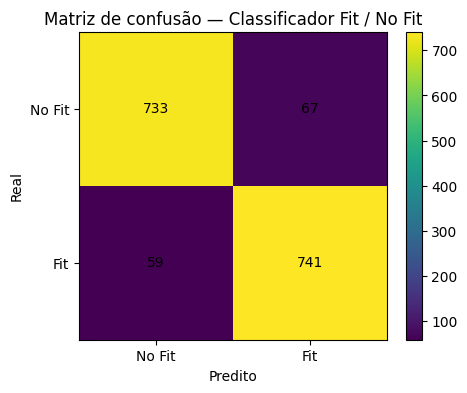

In [18]:
matriz_confusao = metricas_classificacao["matriz_confusao"]

plt.figure(figsize=(5, 4))
plt.imshow(matriz_confusao)
plt.title("Matriz de confusão — Classificador Fit / No Fit")
plt.xticks([0, 1], ["No Fit", "Fit"])
plt.yticks([0, 1], ["No Fit", "Fit"])
plt.xlabel("Predito")
plt.ylabel("Real")

for linha in range(matriz_confusao.shape[0]):
    for coluna in range(matriz_confusao.shape[1]):
        plt.text(
            coluna,
            linha,
            matriz_confusao[linha, coluna],
            ha="center",
            va="center",
        )

plt.colorbar()
plt.show()

A matriz de confusão mostra que o classificador teve desempenho equilibrado entre as duas classes. O modelo acertou `733` exemplos reais de `No Fit` e `741` exemplos reais de `Fit`.

Os erros também ficaram próximos: `67` casos reais de `No Fit` foram previstos como `Fit`, enquanto `59` casos reais de `Fit` foram previstos como `No Fit`. Como os acertos foram muito superiores aos erros, a matriz confirma o bom desempenho geral do classificador.



# Modelo de estimativa salarial

Nesta parte é treinado um modelo de regressão para estimar o salário anual das vagas a partir do texto da descrição. O modelo foi treinado com `8.651` registros e apresentou `MAE = 23.732,91`, `RMSE = 35.458,47` e `R² = 0,5252`, indicando desempenho intermediário na estimativa salarial.

In [19]:
dados_salario = dados_vagas.dropna(subset=["salario_alvo"]).copy()

dados_salario = dados_salario[
    (dados_salario["salario_alvo"] >= 10000)
    & (dados_salario["salario_alvo"] <= 350000)
].copy()

dados_salario = dados_salario[dados_salario["texto_vaga"].str.len() >= 80].copy()

quantidade_maxima_salario = 15000

if len(dados_salario) > quantidade_maxima_salario:
    dados_salario = dados_salario.sample(
        quantidade_maxima_salario,
        random_state=RANDOM_STATE,
    ).reset_index(drop=True)

modelo_estimativa_salario = None
salario_padrao = None
metricas_salario = None

if len(dados_salario) < 100:
    print("Modelo de salário não treinado por falta de dados suficientes.")

    if len(dados_salario) > 0:
        salario_padrao = float(dados_salario["salario_alvo"].median())

else:
    salario_padrao = float(dados_salario["salario_alvo"].median())

    textos_salario_treino, textos_salario_teste, salario_treino, salario_teste = train_test_split(
        dados_salario["texto_vaga"],
        dados_salario["salario_alvo"],
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    vetorizador_temporario = TfidfVectorizer(
        max_features=12000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english",
    )

    matriz_temporaria = vetorizador_temporario.fit_transform(textos_salario_treino)

    quantidade_componentes = min(
        150,
        max(2, matriz_temporaria.shape[1] - 1),
        max(2, matriz_temporaria.shape[0] - 1),
    )

    modelo_estimativa_salario = Pipeline(
        steps=[
            (
                "vetorizador_tfidf",
                TfidfVectorizer(
                    max_features=12000,
                    ngram_range=(1, 2),
                    min_df=2,
                    stop_words="english",
                ),
            ),
            (
                "svd",
                TruncatedSVD(
                    n_components=quantidade_componentes,
                    random_state=RANDOM_STATE,
                ),
            ),
            (
                "regressor",
                RandomForestRegressor(
                    n_estimators=120,
                    max_depth=18,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    modelo_estimativa_salario.fit(textos_salario_treino, salario_treino)

    previsoes_salario = modelo_estimativa_salario.predict(textos_salario_teste)

    metricas_salario = {
        "mae": mean_absolute_error(salario_teste, previsoes_salario),
        "rmse": mean_squared_error(salario_teste, previsoes_salario) ** 0.5,
        "r2": r2_score(salario_teste, previsoes_salario),
    }

    print("Modelo de salário treinado.")
    print("Quantidade usada:", len(dados_salario))
    print("MAE:", metricas_salario["mae"])
    print("RMSE:", metricas_salario["rmse"])
    print("R²:", metricas_salario["r2"])

Modelo de salário treinado.
Quantidade usada: 8651
MAE: 23732.911753575652
RMSE: 35458.471864317595
R²: 0.5251517270364228


# Matriz TF-IDF para ranking

Nesta etapa, os textos das vagas são transformados em matrizes TF-IDF. Nesse contexto, uma matriz considera o conteúdo completo da vaga, enquanto outra usa apenas os títulos. Nesse sentido, essas representações são usadas depois para calcular a similaridade entre o currículo e as vagas disponíveis.


In [20]:
dados_vagas["texto_ranking"] = (
    dados_vagas["title"].fillna("") + " "
    + dados_vagas["title"].fillna("") + " "
    + dados_vagas["title"].fillna("") + " "
    + dados_vagas["skills_desc"].fillna("") + " "
    + dados_vagas["skills_desc"].fillna("") + " "
    + dados_vagas["formatted_experience_level"].fillna("") + " "
    + dados_vagas["formatted_work_type"].fillna("") + " "
    + dados_vagas["description"].fillna("")
).apply(normalizar_texto)

dados_vagas["texto_titulo"] = dados_vagas["title"].fillna("").apply(normalizar_texto)

vetorizador_ranking_vagas = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words="english",
    sublinear_tf=True,
)

matriz_vagas_ranking = vetorizador_ranking_vagas.fit_transform(
    dados_vagas["texto_ranking"]
)

vetorizador_titulos_vagas = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
    sublinear_tf=True,
)

matriz_titulos_vagas = vetorizador_titulos_vagas.fit_transform(
    dados_vagas["texto_titulo"]
)

print("Matriz TF-IDF de vagas criada:", matriz_vagas_ranking.shape)
print("Matriz TF-IDF de títulos criada:", matriz_titulos_vagas.shape)

Matriz TF-IDF de vagas criada: (30000, 30000)
Matriz TF-IDF de títulos criada: (30000, 10000)


# Camada de inferência e recomendação


In [21]:
REFERENCIA_SCORE_TEXTO = 0.45
REFERENCIA_SCORE_TITULO = 0.25

# Limiar mínimo para classificar uma vaga como Fit.
LIMIAR_FIT = 0.50

try:
    normalizar_curriculo_usuario
except NameError:
    def normalizar_curriculo_usuario(valor):
        return normalizar_texto(valor)


# Mantém qualquer valor numérico dentro de um intervalo definido
def limitar_valor(valor, minimo=0.0, maximo=1.0):
    valor = float(valor)

    if valor < minimo:
        return minimo

    if valor > maximo:
        return maximo

    return valor


# Monta a entrada no mesmo formato esperado pelo modelo classificador Fit / No Fit
def montar_entrada_modelo_classificacao(texto_curriculo, texto_vaga):
    curriculo_normalizado = normalizar_curriculo_usuario(texto_curriculo)
    vaga_normalizada = normalizar_texto(texto_vaga)

    texto_par = (
        "curriculo "
        + curriculo_normalizado
        + " vaga "
        + vaga_normalizada
    )

    return pd.DataFrame(
        [
            {
                "texto_par": texto_par,
                "texto_curriculo": curriculo_normalizado,
                "texto_vaga": vaga_normalizada,
            }
        ]
    )


# Calcula a probabilidade de compatibilidade segundo o modelo supervisionado
def obter_probabilidade_modelo(texto_curriculo, texto_vaga):
    if modelo_classificacao_fit is None:
        return None

    entrada_modelo = montar_entrada_modelo_classificacao(
        texto_curriculo=texto_curriculo,
        texto_vaga=texto_vaga,
    )

    return float(modelo_classificacao_fit.predict_proba(entrada_modelo)[0][1])


# Cria uma interpretação qualitativa do score final
def classificar_nivel_aderencia(score_fit):
    if score_fit >= 0.70:
        return "Fit forte"

    if score_fit >= 0.50:
        return "Fit potencial"

    return "No Fit"


# Combina similaridade textual, similaridade com título, cobertura de skills
# e probabilidade do modelo para gerar o score final de Fit
def calcular_score_fit(score_aderencia, score_titulo, cobertura_skills, probabilidade_modelo):
    score_textual_normalizado = limitar_valor(
        score_aderencia / REFERENCIA_SCORE_TEXTO,
        minimo=0.0,
        maximo=1.0,
    )

    score_titulo_normalizado = limitar_valor(
        score_titulo / REFERENCIA_SCORE_TITULO,
        minimo=0.0,
        maximo=1.0,
    )

    cobertura_skills = limitar_valor(
        cobertura_skills,
        minimo=0.0,
        maximo=1.0,
    )

    if probabilidade_modelo is None:
        return float(
            0.50 * score_textual_normalizado
            + 0.30 * score_titulo_normalizado
            + 0.20 * cobertura_skills
        )

    probabilidade_modelo = limitar_valor(
        probabilidade_modelo,
        minimo=0.0,
        maximo=1.0,
    )

    return float(
        0.45 * score_textual_normalizado
        + 0.25 * score_titulo_normalizado
        + 0.20 * cobertura_skills
        + 0.10 * probabilidade_modelo
    )


# Estima o salário anual da vaga usando o modelo de regressão
def estimar_salario_vaga(texto_vaga, vaga):
    if modelo_estimativa_salario is not None:
        salario_estimado = float(
            modelo_estimativa_salario.predict([texto_vaga])[0]
        )

        return max(salario_estimado, 0)

    salario_alvo = vaga.get("salario_alvo")

    if pd.notna(salario_alvo):
        return float(salario_alvo)

    min_salary = vaga.get("min_salary")
    max_salary = vaga.get("max_salary")

    if pd.notna(min_salary) and pd.notna(max_salary):
        return float((min_salary + max_salary) / 2)

    return salario_padrao

def recomendar_top_vagas(texto_curriculo, quantidade=5, quantidade_candidatas=100):
    curriculo_normalizado = normalizar_curriculo_usuario(texto_curriculo)

    # Vetoriza o currículo para comparar com o conteúdo completo das vagas
    vetor_curriculo = vetorizador_ranking_vagas.transform(
        [curriculo_normalizado]
    )

    # Vetoriza o currículo para comparar especificamente com os títulos das vagas
    vetor_curriculo_titulo = vetorizador_titulos_vagas.transform(
        [curriculo_normalizado]
    )

    # Calcula similaridade entre currículo e texto completo das vagas
    scores_aderencia = cosine_similarity(
        vetor_curriculo,
        matriz_vagas_ranking,
    ).ravel()

    # Calcula similaridade entre currículo e títulos das vagas
    scores_titulo = cosine_similarity(
        vetor_curriculo_titulo,
        matriz_titulos_vagas,
    ).ravel()

    quantidade_candidatas = min(
        quantidade_candidatas,
        len(dados_vagas),
    )

    # Seleciona as vagas mais promissoras pela similaridade textual inicial
    indices_candidatas = np.argsort(scores_aderencia)[::-1][:quantidade_candidatas]

    vagas_candidatas = dados_vagas.iloc[indices_candidatas].copy()
    textos_candidatas = vagas_candidatas["texto_vaga"].tolist()

    # Extrai as principais skills das vagas candidatas
    skills_candidatas = extrair_skills_de_textos(
        textos=textos_candidatas,
        limite=15,
    )

    resultados = []

    for posicao, indice_original in enumerate(indices_candidatas):
        vaga = dados_vagas.iloc[indice_original]

        texto_vaga = vaga["texto_vaga"]
        score_aderencia = float(scores_aderencia[indice_original])
        score_titulo = float(scores_titulo[indice_original])
        skills_vaga = skills_candidatas[posicao]

        # Compara as skills da vaga com as skills identificadas no currículo
        skills_compativeis, skills_faltantes = comparar_skills(
            texto_curriculo=curriculo_normalizado,
            skills_vaga=skills_vaga,
        )

        cobertura_skills = calcular_cobertura_skills(
            skills_compativeis=skills_compativeis,
            skills_faltantes=skills_faltantes,
        )

        probabilidade_modelo = obter_probabilidade_modelo(
            texto_curriculo=curriculo_normalizado,
            texto_vaga=texto_vaga,
        )

        # Calcula o score final
        score_fit = calcular_score_fit(
            score_aderencia=score_aderencia,
            score_titulo=score_titulo,
            cobertura_skills=cobertura_skills,
            probabilidade_modelo=probabilidade_modelo,
        )

        classificacao = "Fit" if score_fit >= LIMIAR_FIT else "No Fit"

        salario_estimado = estimar_salario_vaga(
            texto_vaga=texto_vaga,
            vaga=vaga,
        )

        resultados.append(
            {
                "indice_vaga": int(indice_original),
                "job_id": vaga["job_id"],
                "titulo_vaga": vaga["title"],
                "empresa": vaga["company_name"],
                "localizacao": vaga["location"],
                "score_aderencia": round(score_aderencia, 4),
                "score_titulo": round(score_titulo, 4),
                "cobertura_skills": round(cobertura_skills, 4),
                "probabilidade_modelo_fit": round(probabilidade_modelo, 4) if probabilidade_modelo is not None else None,
                "score_fit": round(score_fit, 4),
                "classificacao": classificacao,
                "nivel_aderencia": classificar_nivel_aderencia(score_fit),
                "skills_compativeis": skills_compativeis[:10],
                "skills_faltantes": skills_faltantes[:10],
                "sugestao_desenvolvimento": gerar_sugestao_desenvolvimento(skills_faltantes),
                "salario_estimado_anual": round(salario_estimado, 2) if salario_estimado is not None else None,
                "moeda": vaga["currency"],
            }
        )

    resultado = pd.DataFrame(resultados)

    # Ordena as vagas pelo score final
    resultado = resultado.sort_values(
        by="score_fit",
        ascending=False,
    ).head(quantidade)

    return resultado.reset_index(drop=True)


print("Camada de inferência e recomendação carregada")

Camada de inferência e recomendação carregada


# teste do sistema

In [22]:
texto_curriculo_teste = (
    "I am a data professional with experience in Python, SQL, pandas, "
    "machine learning, data analysis, APIs, Docker, dashboards and predictive modeling. "
    "I have worked with data pipelines, business indicators and model evaluation."
)

vagas_recomendadas = recomendar_top_vagas(
    texto_curriculo=texto_curriculo_teste,
    quantidade=5,
    quantidade_candidatas=100,
)

display(vagas_recomendadas)

,indice_vaga,job_id,titulo_vaga,empresa,localizacao,score_aderencia,score_titulo,cobertura_skills,probabilidade_modelo_fit,score_fit,classificacao,nivel_aderencia,skills_compativeis,skills_faltantes,sugestao_desenvolvimento,salario_estimado_anual,moeda
0,6012,3904090577,Lead Machine Learning Engineer,maven,Greater Chicago Area,0.2518,0.2771,1.0000,0.0629,0.7081,Fit,Fit forte,"[machine learning, data pipelines, python]",[],Perfil bem alinhado. Manter portfólio atualiza...,177640.13,USD
1,1203,3901377477,AI/ML Solutions Architect (Data Analysis skill...,InfoVision Inc.,"Irving, TX",0.2262,0.3637,0.3571,0.0396,0.5516,Fit,Fit potencial,"[machine learning, data analysis, modeling, py...","[solution architecture, analytical skills, Dat...",Priorizar desenvolvimento em: solution archite...,156422.76,USD
2,16109,3902828481,Remote opportunity for P&C Insurance Data Scie...,Pryor Associates Executive Search,United States,0.2348,0.0878,0.8571,0.4697,0.5410,Fit,Fit potencial,"[predictive modeling, machine learning, modeli...",[data science],Priorizar desenvolvimento em: data science. Cr...,163739.96,USD
3,11433,3905236643,Senior Machine Learning Engineer,Harnham,United States,0.2063,0.2856,0.2000,0.0104,0.4973,No Fit,No Fit,"[machine learning, modeling, python]","[operational efficiency, data analytics, deep ...",Priorizar desenvolvimento em: operational effi...,184159.83,USD
4,9883,3906088296,Senior Machine Learning Engineer,Commit: AI Career Agents for Developers,United States,0.1697,0.2856,0.3636,0.0158,0.4940,No Fit,No Fit,"[machine learning, data pipeline, python, sql]","[natural language processing, Big Data, engine...",Priorizar desenvolvimento em: natural language...,167326.97,USD


# Teste em português

In [23]:
perfis_teste_portugues = [
    {
        "nome": "Dados e Machine Learning",
        "curriculo": (
            "Sou profissional de dados com experiência em Python, SQL, pandas, "
            "aprendizado de máquina, análise de dados, APIs, Docker, dashboards "
            "e modelagem preditiva. Trabalhei com pipelines de dados, indicadores "
            "de negócio e avaliação de modelos."
        ),
    },
    {
        "nome": "Frontend",
        "curriculo": (
            "Sou desenvolvedor frontend com experiência em React, TypeScript, "
            "JavaScript, HTML, CSS, criação de interfaces, componentes reutilizáveis "
            "e aplicações web responsivas."
        ),
    },
    {
        "nome": "DevOps e Cloud",
        "curriculo": (
            "Sou profissional de infraestrutura e DevOps com experiência em Docker, "
            "Kubernetes, AWS, Linux, CI CD, automação, monitoramento e cloud computing."
        ),
    },
]

resultados_testes_portugues = []

for perfil in perfis_teste_portugues:
    recomendacoes = recomendar_top_vagas(
        texto_curriculo=perfil["curriculo"],
        quantidade=5,
        quantidade_candidatas=100,
    )

    recomendacoes.insert(0, "perfil_teste", perfil["nome"])
    resultados_testes_portugues.append(recomendacoes)

resultado_portugues = pd.concat(
    resultados_testes_portugues,
    ignore_index=True,
)

display(
    resultado_portugues[
        [
            "perfil_teste",
            "titulo_vaga",
            "score_aderencia",
            "cobertura_skills",
            "probabilidade_modelo_fit",
            "score_fit",
            "classificacao",
            "skills_compativeis",
            "skills_faltantes",
        ]
    ]
)

,perfil_teste,titulo_vaga,score_aderencia,cobertura_skills,probabilidade_modelo_fit,score_fit,classificacao,skills_compativeis,skills_faltantes
0,Dados e Machine Learning,Lead Machine Learning Engineer,0.2422,1.0000,0.0459,0.6968,Fit,"[machine learning, data pipelines, python]",[]
1,Dados e Machine Learning,Remote opportunity for P&C Insurance Data Scie...,0.2270,0.8571,0.3763,0.5228,Fit,"[predictive modeling, machine learning, modeli...",[data science]
2,Dados e Machine Learning,AI/ML Solutions Architect (Data Analysis skill...,0.1897,0.3571,0.0285,0.5140,Fit,"[machine learning, data analysis, modeling, py...","[solution architecture, analytical skills, Dat..."
3,Dados e Machine Learning,Senior Machine Learning Engineer,0.1983,0.2000,0.0089,0.4892,No Fit,"[machine learning, modeling, python]","[operational efficiency, data analytics, deep ..."
4,Dados e Machine Learning,Senior Machine Learning Engineer,0.1630,0.3636,0.0127,0.4870,No Fit,"[machine learning, data pipeline, python, sql]","[natural language processing, Big Data, engine..."
5,Frontend,Senior Frontend Developer(React),0.2515,1.0000,0.9468,0.7962,Fit,"[typescript, react]",[]
6,Frontend,Frontend Developer,0.3078,0.5000,0.6509,0.7095,Fit,"[HTML, CSS]","[self-starter, HubSpot]"
7,Frontend,Frontend Developer,0.2375,0.5000,0.8988,0.6639,Fit,"[react, CSS]","[Communication Skills, self-starter]"
8,Frontend,Frontend Developer React,0.2739,0.4444,0.4053,0.6534,Fit,"[javascript, react, HTML, CSS]","[Software Development, web development, proble..."
9,Frontend,Javascript Developer,0.2248,0.5000,0.4278,0.6176,Fit,"[javascript, react, HTML]","[critical thinking, web development, Netsuite]"


#análise visual do Top-5

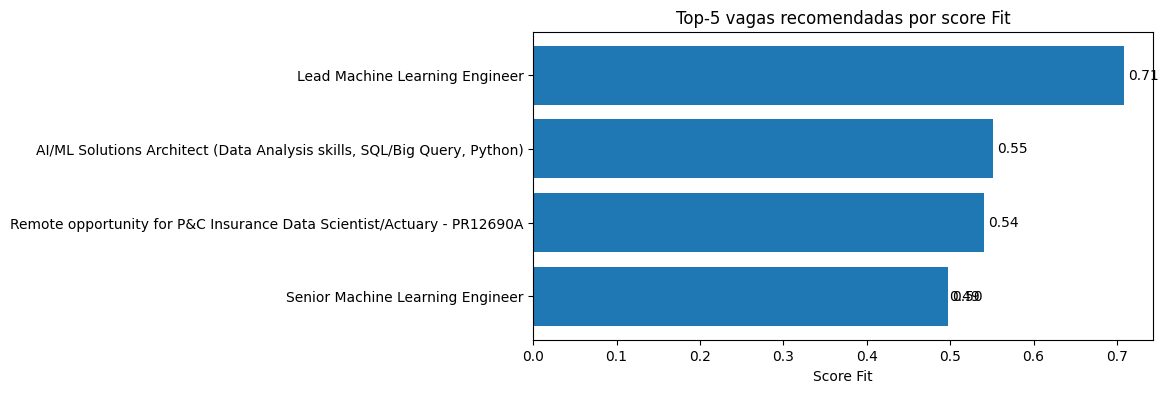

In [24]:
plt.figure(figsize=(8, 4))

barras = plt.barh(
    vagas_recomendadas["titulo_vaga"][::-1],
    vagas_recomendadas["score_fit"][::-1],
)

plt.bar_label(
    barras,
    fmt="%.2f",
    padding=3,
)

plt.title("Top-5 vagas recomendadas por score Fit")
plt.xlabel("Score Fit")
plt.show()

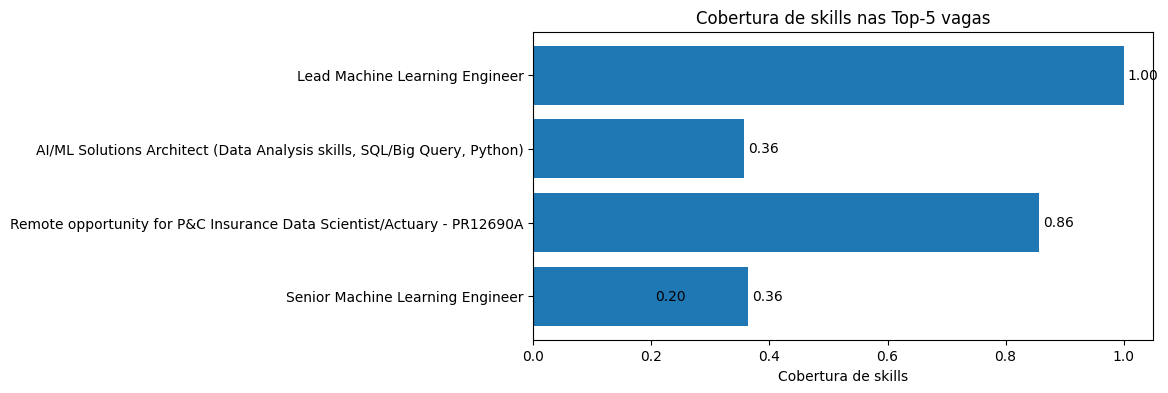

In [25]:
plt.figure(figsize=(8, 4))

barras = plt.barh(
    vagas_recomendadas["titulo_vaga"][::-1],
    vagas_recomendadas["cobertura_skills"][::-1],
)

plt.bar_label(
    barras,
    fmt="%.2f",
    padding=3,
)

plt.title("Cobertura de skills nas Top-5 vagas")
plt.xlabel("Cobertura de skills")
plt.show()

# avaliação simples do recomendador

In [26]:
casos_avaliacao = [
    {
        "perfil": (
            "Python SQL pandas machine learning statistics predictive modeling "
            "data analysis dashboards data pipelines"
        ),
        "termos_esperados": ["data scientist", "machine learning", "analytics", "data analyst"],
    },
    {
        "perfil": (
            "React TypeScript JavaScript HTML CSS frontend development "
            "web applications user interface"
        ),
        "termos_esperados": ["frontend", "react", "javascript", "web developer"],
    },
    {
        "perfil": (
            "Docker Kubernetes AWS cloud CI CD Linux infrastructure monitoring "
            "DevOps automation"
        ),
        "termos_esperados": ["devops", "cloud", "kubernetes", "infrastructure"],
    },
]


def avaliar_recomendador(casos, quantidade=5):
    resultados_avaliacao = []

    for caso in casos:
        recomendacoes = recomendar_top_vagas(
            texto_curriculo=caso["perfil"],
            quantidade=quantidade,
            quantidade_candidatas=100,
        )

        relevantes = []

        for _, linha in recomendacoes.iterrows():
            indice_vaga = int(linha["indice_vaga"])
            texto_vaga = dados_vagas.iloc[indice_vaga]["texto_vaga"]

            relevante = any(
                normalizar_texto(termo) in texto_vaga
                for termo in caso["termos_esperados"]
            )

            relevantes.append(int(relevante))

        precision_at_k = sum(relevantes) / quantidade

        resultados_avaliacao.append(
            {
                "perfil_avaliado": caso["perfil"][:60] + "...",
                "precision_at_5_proxy": round(precision_at_k, 4),
                "vagas_relevantes_no_top_5": sum(relevantes),
            }
        )

    return pd.DataFrame(resultados_avaliacao)


metricas_recomendador = avaliar_recomendador(
    casos=casos_avaliacao,
    quantidade=5,
)

display(metricas_recomendador)

,perfil_avaliado,precision_at_5_proxy,vagas_relevantes_no_top_5
0,Python SQL pandas machine learning statistics ...,1.0,5
1,React TypeScript JavaScript HTML CSS frontend ...,1.0,5
2,Docker Kubernetes AWS cloud CI CD Linux infras...,1.0,5


# Limitações e Análise de Erros

A tabela ajuda a revisar as recomendações geradas, considerando score de aderência, cobertura de skills, probabilidade do modelo e classificação final.

As principais limitações estão relacionadas a descrições genéricas de vagas, extração de skills pouco específicas, ausência de rótulos reais de relevância na base LinkedIn e diferença entre a base usada para treinar o classificador e a base usada na recomendação.


In [27]:
colunas_analise = [
    "titulo_vaga",
    "score_aderencia",
    "cobertura_skills",
    "probabilidade_modelo_fit",
    "score_fit",
    "classificacao",
    "skills_compativeis",
    "skills_faltantes",
]

display(vagas_recomendadas[colunas_analise])

,titulo_vaga,score_aderencia,cobertura_skills,probabilidade_modelo_fit,score_fit,classificacao,skills_compativeis,skills_faltantes
0,Lead Machine Learning Engineer,0.2518,1.0000,0.0629,0.7081,Fit,"[machine learning, data pipelines, python]",[]
1,AI/ML Solutions Architect (Data Analysis skill...,0.2262,0.3571,0.0396,0.5516,Fit,"[machine learning, data analysis, modeling, py...","[solution architecture, analytical skills, Dat..."
2,Remote opportunity for P&C Insurance Data Scie...,0.2348,0.8571,0.4697,0.5410,Fit,"[predictive modeling, machine learning, modeli...",[data science]
3,Senior Machine Learning Engineer,0.2063,0.2000,0.0104,0.4973,No Fit,"[machine learning, modeling, python]","[operational efficiency, data analytics, deep ..."
4,Senior Machine Learning Engineer,0.1697,0.3636,0.0158,0.4940,No Fit,"[machine learning, data pipeline, python, sql]","[natural language processing, Big Data, engine..."


#resumo das métricas

In [28]:
print("Resumo do JobMatch AI")

print("\nBase LinkedIn")
print("Vagas usadas:", len(dados_vagas))

print("\nClassificação Fit / No Fit")

if metricas_classificacao is None:
    print("Classificador supervisionado não treinado.")
    print("Classificação final feita por score textual + cobertura de skills.")
else:
    print("Acurácia:", metricas_classificacao["acuracia"])
    print("Matriz de confusão:")
    print(metricas_classificacao["matriz_confusao"])

print("\nRegressão salarial")

if metricas_salario is None:
    print("Modelo salarial não treinado.")
    print("Fallback:", salario_padrao)
else:
    print("MAE:", metricas_salario["mae"])
    print("RMSE:", metricas_salario["rmse"])
    print("R²:", metricas_salario["r2"])

print("\nRecomendação Top-5")
display(metricas_recomendador)

Resumo do JobMatch AI

Base LinkedIn
Vagas usadas: 30000

Classificação Fit / No Fit
Acurácia: 0.92125
Matriz de confusão:
[[733  67]
 [ 59 741]]

Regressão salarial
MAE: 23732.911753575652
RMSE: 35458.471864317595
R²: 0.5251517270364228

Recomendação Top-5


,perfil_avaliado,precision_at_5_proxy,vagas_relevantes_no_top_5
0,Python SQL pandas machine learning statistics ...,1.0,5
1,React TypeScript JavaScript HTML CSS frontend ...,1.0,5
2,Docker Kubernetes AWS cloud CI CD Linux infras...,1.0,5


# modelo

In [29]:
objetos_necessarios = [
    "dados_vagas",
    "modelo_classificacao_fit",
    "modelo_estimativa_salario",
    "vetorizador_ranking_vagas",
    "matriz_vagas_ranking",
    "vetorizador_titulos_vagas",
    "matriz_titulos_vagas",
    "vetorizador_skills",
    "nomes_skills",
    "skill_original_por_normalizada",
    "salario_padrao",
    "REFERENCIA_SCORE_TEXTO",
    "REFERENCIA_SCORE_TITULO",
    "LIMIAR_FIT",
]

objetos_faltando = [
    nome for nome in objetos_necessarios
    if nome not in globals()
]

if objetos_faltando:
    print("Objetos faltando:")
    for nome in objetos_faltando:
        print("-", nome)
else:
    print("Todos os objetos necessários estão disponíveis.")

Todos os objetos necessários estão disponíveis.


# salvar o artefato

In [30]:
!pip -q install cloudpickle

In [31]:
import gzip
import cloudpickle
from pathlib import Path

objetos_necessarios = [
    "dados_vagas",
    "modelo_classificacao_fit",
    "modelo_estimativa_salario",
    "vetorizador_ranking_vagas",
    "matriz_vagas_ranking",
    "vetorizador_titulos_vagas",
    "matriz_titulos_vagas",
    "vetorizador_skills",
    "nomes_skills",
    "skill_original_por_normalizada",
    "salario_padrao",
    "REFERENCIA_SCORE_TEXTO",
    "REFERENCIA_SCORE_TITULO",
    "LIMIAR_FIT",
]

objetos_faltando = [
    nome for nome in objetos_necessarios
    if nome not in globals()
]

if objetos_faltando:
    raise NameError(
        "Execute antes as células que criam estes objetos: "
        + ", ".join(objetos_faltando)
    )

caminho_artefatos = Path("artifacts")
caminho_artefatos.mkdir(parents=True, exist_ok=True)

artefatos_jobmatch = {
    "dados_vagas": dados_vagas,
    "modelo_classificacao_fit": modelo_classificacao_fit,
    "modelo_estimativa_salario": modelo_estimativa_salario,
    "vetorizador_ranking_vagas": vetorizador_ranking_vagas,
    "matriz_vagas_ranking": matriz_vagas_ranking,
    "vetorizador_titulos_vagas": vetorizador_titulos_vagas,
    "matriz_titulos_vagas": matriz_titulos_vagas,
    "vetorizador_skills": vetorizador_skills,
    "nomes_skills": nomes_skills,
    "skill_original_por_normalizada": skill_original_por_normalizada,
    "salario_padrao": salario_padrao,
    "referencia_score_texto": REFERENCIA_SCORE_TEXTO,
    "referencia_score_titulo": REFERENCIA_SCORE_TITULO,
    "limiar_fit": LIMIAR_FIT,
    "limiar_modelo_fit": LIMIAR_MODELO_FIT if "LIMIAR_MODELO_FIT" in globals() else None,
    "metricas_classificacao": metricas_classificacao if "metricas_classificacao" in globals() else None,
    "metricas_salario": metricas_salario if "metricas_salario" in globals() else None,
}

caminho_modelo = caminho_artefatos / "jobmatch_ai_artifacts.pkl.gz"

with gzip.open(caminho_modelo, "wb") as arquivo:
    cloudpickle.dump(artefatos_jobmatch, arquivo)

print("Artefato salvo em:", caminho_modelo)

Artefato salvo em: artifacts/jobmatch_ai_artifacts.pkl.gz


In [32]:
# baixar o arquivo
from google.colab import files

files.download("artifacts/jobmatch_ai_artifacts.pkl.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>